# Experiments 6–8: Poetry Aesthetics — Validation, Dynasty, & Bilingual Distillation

**Exp 6 — Real Poetry Validation**: Do aesthetic neurons (from Exp 2/5) fire on *real* poetry?  
**Exp 7 — Dynasty Aesthetics**: Tang (奔放) vs Song (婉约) — can the model distinguish dynastic aesthetics?  
**Exp 8 — Bilingual Distillation**: Same poem in ZH vs EN — separate content neurons from style neurons.

**Data**: larryvrh/Chinese-Poems (217K), biglam/gutenberg-poetry-corpus (3M lines),  
andreamorgar/spanish_poetry (5K), emmit989/chinese-poetry-trans (707 bilingual pairs), WMT19 zh-en news.

**Model**: Qwen3-8B Q4_K_M (36 layers, 4096 dim)  
**Builds on**: Exp 2 (aesthetic direction), Exp 5 (causal neurons), §11–12 (cross-lingual sets)

## §1 Setup & Load Previous Results

In [1]:
import os, sys, time, json, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from scipy import stats

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.environ['TORCH_HOME'] = '/workspace/Data/torch_cache'
sys.path.insert(0, '/workspace/NeuroScope/build/python')
import neuroscope

# CJK fonts
for f in fm.findSystemFonts():
    if 'noto' in f.lower() and 'cjk' in f.lower():
        fm.fontManager.addfont(f)
plt.rcParams.update({
    'font.family': ['Noto Sans CJK SC', 'sans-serif'],
    'axes.unicode_minus': False, 'figure.dpi': 150, 'figure.facecolor': 'white',
})

# Paths
MODEL_PATH = '/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf'
EXP2_DIR   = Path('/workspace/Data/aesthetic_experiment')
EXP5_DIR   = Path('/workspace/Data/aesthetic_neurons')
POETRY_DIR = Path('/workspace/Data/poetry_data')
OUTPUT_DIR = Path('/workspace/Data/poetry_aesthetics')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NOTHINK_SUFFIX = '<think>\n\n</think>\n\n'
SEED = 42
np.random.seed(SEED)

# --- Load Exp 2 / 5 results ---
exp2_results = np.load(EXP2_DIR / 'aesthetic_analysis_results.npz', allow_pickle=True)
exp5_results = np.load(EXP5_DIR / 'ablation_results.npz', allow_pickle=True)

aesthetic_dir_norm = exp2_results['aesthetic_direction_norm']  # (36, 4096)
best_layer = int(exp2_results['best_cls_layer'])
selectivity   = exp5_results['selectivity']        # (36, 4096)
contribution  = exp5_results['contribution']       # (36, 4096)
neuron_auc_drop = exp5_results['neuron_auc_drop']  # (4096,)

N_LAYERS, N_EMBD = aesthetic_dir_norm.shape

# Top-100 aesthetic neurons by contribution at best layer
top_aesthetic = np.argsort(contribution[best_layer])[-100:][::-1]

# Aesthetic vocabulary (same as Exp 5)
AESTHETIC_WORDS = {
    'beautiful', 'beautifully', 'beauty', 'elegant', 'elegantly', 'elegance',
    'graceful', 'gracefully', 'stunning', 'stunningly', 'gorgeous', 'gorgeously',
    'magnificent', 'magnificently', 'magnificence', 'splendid', 'splendidly',
    'exquisite', 'exquisitely', 'sublime', 'sublimely', 'serene', 'serenely',
    'serenity', 'harmonious', 'harmoniously', 'harmony', 'delicate', 'delicately',
    'delicacy', 'radiant', 'radiantly', 'radiance', 'breathtaking', 'breathtakingly',
    'enchanting', 'enchantingly', 'lovely', 'loveliness', 'majestic', 'majestically',
    'majesty', 'glorious', 'gloriously', 'dazzling', 'dazzlingly', 'aesthetic',
    'aesthetically', 'poetic', 'poetically', 'picturesque', 'idyllic', 'ethereal',
    'pristine', 'vibrant', 'vibrantly', 'vibrancy', 'lush', 'lushness', 'tranquil',
    'tranquility', 'charming', 'charmingly', 'alluring', 'allure', 'captivating',
    'mesmerizing', 'resplendent', 'opulent', 'opulence', 'spectacular', 'spectacularly',
    'wonderful', 'wonderfully', 'glowing', 'dreamy', 'artistic', 'ornate',
}

print(f'NeuroScope {neuroscope.__version__}, CUDA: {neuroscope.cuda_available()}')
print(f'Exp2/5 loaded: {N_LAYERS}L × {N_EMBD}D, best_layer={best_layer}')
print(f'Top-100 aesthetic neurons (L{best_layer}): {top_aesthetic[:10].tolist()}...')

NeuroScope 1.2.3, CUDA: True
Exp2/5 loaded: 36L × 4096D, best_layer=16
Top-100 aesthetic neurons (L16): [3470, 2276, 716, 809, 3775, 2001, 3179, 1291, 2826, 2275]...


In [2]:
# §2 Load engine
engine = neuroscope.Engine(MODEL_PATH, n_ctx=4096, n_seq_max=1)
info = engine.model_info
print(f'Model: {info.name} ({info.n_layers}L, {info.n_embd}D, ctx={info.n_ctx})')

Model: Qwen3 8B Awq Compatible Instruct (36L, 4096D, ctx=4096)


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 98041428
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 98041428
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 95743 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           general.f

In [3]:
# §3 Load poetry corpora + news baseline
with open(POETRY_DIR / 'chinese_poems.json', encoding='utf-8') as f:
    zh_poems_all = json.load(f)
with open(POETRY_DIR / 'english_poems.json', encoding='utf-8') as f:
    en_poems_all = json.load(f)
with open(POETRY_DIR / 'spanish_poems.json', encoding='utf-8') as f:
    es_poems_all = json.load(f)
with open(POETRY_DIR / 'wmt19_news.json', encoding='utf-8') as f:
    news_all = json.load(f)
with open(POETRY_DIR / 'bilingual_poems.json', encoding='utf-8') as f:
    bilingual_all = json.load(f)

# Dynasty breakdown
zh_by_dynasty = {}
for p in zh_poems_all:
    zh_by_dynasty.setdefault(p['dynasty'], []).append(p)

rng = np.random.RandomState(SEED)

# --- Sample N=50 per category for Exp 6 ---
N_SAMPLE = 50

def sample_texts(items, key, n):
    idx = rng.choice(len(items), min(n, len(items)), replace=False)
    return [items[i][key] for i in idx]

zh_poetry_texts = sample_texts(zh_poems_all, 'content', N_SAMPLE)
en_poetry_texts = sample_texts(en_poems_all, 'content', N_SAMPLE)
es_poetry_texts = sample_texts(es_poems_all, 'content', N_SAMPLE)
zh_news_texts   = sample_texts(news_all, 'zh', N_SAMPLE)
en_news_texts   = sample_texts(news_all, 'en', N_SAMPLE)

print(f'Poetry:  ZH={len(zh_poetry_texts)}, EN={len(en_poetry_texts)}, ES={len(es_poetry_texts)}')
print(f'News:    ZH={len(zh_news_texts)}, EN={len(en_news_texts)}')
print(f'Dynasty: {", ".join(f"{k}({len(v)})" for k,v in sorted(zh_by_dynasty.items(), key=lambda x:-len(x[1])))}')
print(f'Bilingual pairs: {len(bilingual_all)}')
print(f'\nSample ZH poem: {zh_poetry_texts[0][:80]}...')
print(f'Sample EN poem: {en_poetry_texts[0][:80]}...')
print(f'Sample ZH news: {zh_news_texts[0][:80]}...')

Poetry:  ZH=50, EN=50, ES=50
News:    ZH=50, EN=50
Dynasty: 唐代(2000), 宋代(2000), 清代(300), 明代(300), 元代(300)
Bilingual pairs: 707

Sample ZH poem: 鉴湖春日
雁啼秋水移冰柱，蚁泛春波倒玉壶，绿杨花谢燕将雏。人笑语，游遍贺家湖。
金华客舍
落红小雨苍苔径，飞絮东风细柳营，可怜客里过清明。不待听，昨夜杜鹃声。
...
Sample EN poem: Entered according to Act of Congress, in the year 1883, by
_All rights reserved....
Sample ZH news: 习近平出席中国共产党与世界政党高层对话会开幕式并发表主旨讲话，王沪宁出席对话会第一次全体会议。...


## Experiment 6: Real Poetry Validation

**Question**: Do aesthetic neurons identified in Exp 2/5 (via prompt-generated text) also activate for **real poetry**?

**Method**: Feed real poems and news articles through `engine.forward()`, collect last-token activations, project onto aesthetic direction, and compare projections between categories.

**Prediction**: Poetry → higher projection onto aesthetic direction → top aesthetic neurons more active.

In [4]:
# §4 Collect activations: Poetry vs News
# For each text: forward through model, get last-token activation at best_layer
# Then project onto aesthetic_direction_norm to get "aesthetic score"

def collect_activations(texts, label, max_chars=300):
    """Forward each text, collect activation at best_layer."""
    acts_list = []
    t0 = time.time()
    for i, text in enumerate(texts):
        # Truncate very long texts to fit context
        text_trunc = text[:max_chars]
        engine.reset()
        ok = engine.forward(text_trunc)
        if ok:
            act = engine.get_activations(best_layer)  # (4096,)
            acts_list.append(act.copy())
        if (i+1) % 25 == 0:
            print(f'  {label}: {i+1}/{len(texts)} ({time.time()-t0:.1f}s)')
    print(f'  {label}: {len(acts_list)}/{len(texts)} collected in {time.time()-t0:.1f}s')
    return np.array(acts_list)  # (N, 4096)

print(f'=== Collecting activations at Layer {best_layer} ===')
acts_zh_poetry = collect_activations(zh_poetry_texts, 'ZH-Poetry')
acts_en_poetry = collect_activations(en_poetry_texts, 'EN-Poetry')
acts_es_poetry = collect_activations(es_poetry_texts, 'ES-Poetry')
acts_zh_news   = collect_activations(zh_news_texts,   'ZH-News')
acts_en_news   = collect_activations(en_news_texts,   'EN-News')

# Project onto aesthetic direction
d_vec = aesthetic_dir_norm[best_layer]  # (4096,)

proj = {}
for name, acts in [('ZH-Poetry', acts_zh_poetry), ('EN-Poetry', acts_en_poetry),
                    ('ES-Poetry', acts_es_poetry), ('ZH-News', acts_zh_news),
                    ('EN-News', acts_en_news)]:
    proj[name] = acts @ d_vec  # (N,) — projection onto aesthetic direction

print(f'\n=== Aesthetic Projections ===')
for name, p in proj.items():
    print(f'  {name:12s}: mean={p.mean():.3f} ± {p.std():.3f}  (min={p.min():.3f}, max={p.max():.3f})')

=== Collecting activations at Layer 16 ===
  ZH-Poetry: 25/50 (1.4s)
  ZH-Poetry: 50/50 (2.6s)
  ZH-Poetry: 50/50 collected in 2.6s
  EN-Poetry: 25/50 (1.3s)
  EN-Poetry: 50/50 (2.6s)
  EN-Poetry: 50/50 collected in 2.6s
  ES-Poetry: 25/50 (1.4s)
  ES-Poetry: 50/50 (2.7s)
  ES-Poetry: 50/50 collected in 2.7s
  ZH-News: 25/50 (1.1s)
  ZH-News: 50/50 (2.2s)
  ZH-News: 50/50 collected in 2.2s
  EN-News: 25/50 (1.1s)
  EN-News: 50/50 (2.2s)
  EN-News: 50/50 collected in 2.2s

=== Aesthetic Projections ===
  ZH-Poetry   : mean=4.875 ± 1.334  (min=1.783, max=6.914)
  EN-Poetry   : mean=3.240 ± 1.584  (min=0.651, max=7.988)
  ES-Poetry   : mean=3.854 ± 1.572  (min=-0.153, max=7.204)
  ZH-News     : mean=3.843 ± 1.607  (min=1.273, max=8.357)
  EN-News     : mean=3.077 ± 1.701  (min=-0.800, max=6.620)


In [5]:
# §5 Exp 6 Analysis: Statistical tests + neuron-level validation

# (A) Poetry vs News — does poetry activate the aesthetic direction more?
poetry_all = np.concatenate([proj['ZH-Poetry'], proj['EN-Poetry'], proj['ES-Poetry']])
news_all   = np.concatenate([proj['ZH-News'], proj['EN-News']])

t_stat, p_val = stats.ttest_ind(poetry_all, news_all)
cohens_d = (poetry_all.mean() - news_all.mean()) / np.sqrt((poetry_all.std()**2 + news_all.std()**2) / 2)
print(f'=== Poetry vs News (aesthetic projection) ===')
print(f'  Poetry: {poetry_all.mean():.3f} ± {poetry_all.std():.3f} (n={len(poetry_all)})')
print(f'  News:   {news_all.mean():.3f} ± {news_all.std():.3f} (n={len(news_all)})')
print(f'  t={t_stat:.3f}, p={p_val:.2e}, Cohen\'s d={cohens_d:.3f}')

# (B) Per-language comparison
print(f'\n=== Per-Language Comparison ===')
for lang in ['ZH', 'EN']:
    pp = proj[f'{lang}-Poetry']
    nn = proj[f'{lang}-News']
    t, p = stats.ttest_ind(pp, nn)
    d = (pp.mean() - nn.mean()) / np.sqrt((pp.std()**2 + nn.std()**2) / 2)
    print(f'  {lang}: Poetry={pp.mean():.3f}±{pp.std():.3f} vs News={nn.mean():.3f}±{nn.std():.3f}  t={t:.2f}, p={p:.2e}, d={d:.3f}')

# (C) Top aesthetic neurons: are they more active for poetry?
# Compare mean activation of top-100 aesthetic neurons: poetry vs news
acts_poetry_concat = np.concatenate([acts_zh_poetry, acts_en_poetry, acts_es_poetry])
acts_news_concat   = np.concatenate([acts_zh_news, acts_en_news])

top100_mean_poetry = acts_poetry_concat[:, top_aesthetic[:100]].mean(0)  # (100,)
top100_mean_news   = acts_news_concat[:, top_aesthetic[:100]].mean(0)    # (100,)
# Also get random-100 neurons for control
rng2 = np.random.RandomState(99)
random100 = rng2.choice(N_EMBD, 100, replace=False)
rand100_mean_poetry = acts_poetry_concat[:, random100].mean(0)
rand100_mean_news   = acts_news_concat[:, random100].mean(0)

# Absolute activation difference
top_diff = np.abs(top100_mean_poetry) - np.abs(top100_mean_news)
rand_diff = np.abs(rand100_mean_poetry) - np.abs(rand100_mean_news)
print(f'\n=== Top-100 Aesthetic Neurons: Activation Difference (|poetry| - |news|) ===')
print(f'  Aesthetic top-100: mean diff = {top_diff.mean():.4f}  ({(top_diff > 0).sum()}/100 higher for poetry)')
print(f'  Random-100:        mean diff = {rand_diff.mean():.4f}  ({(rand_diff > 0).sum()}/100 higher for poetry)')

# (D) Classification: can we distinguish poetry from news using aesthetic projection?
from sklearn.metrics import roc_auc_score
all_proj_vals = np.concatenate([poetry_all, news_all])
all_labels = np.array([1]*len(poetry_all) + [0]*len(news_all))
auc = roc_auc_score(all_labels, all_proj_vals)
print(f'\n=== Classification AUC (poetry vs news via aesthetic projection) ===')
print(f'  AUC = {auc:.4f}')

=== Poetry vs News (aesthetic projection) ===
  Poetry: 3.990 ± 1.646 (n=150)
  News:   3.460 ± 1.698 (n=100)
  t=2.451, p=1.49e-02, Cohen's d=0.317

=== Per-Language Comparison ===
  ZH: Poetry=4.875±1.334 vs News=3.843±1.607  t=3.46, p=8.03e-04, d=0.699
  EN: Poetry=3.240±1.584 vs News=3.077±1.701  t=0.49, p=6.25e-01, d=0.099

=== Top-100 Aesthetic Neurons: Activation Difference (|poetry| - |news|) ===
  Aesthetic top-100: mean diff = -0.2190  (41/100 higher for poetry)
  Random-100:        mean diff = -0.0506  (51/100 higher for poetry)

=== Classification AUC (poetry vs news via aesthetic projection) ===
  AUC = 0.5937


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

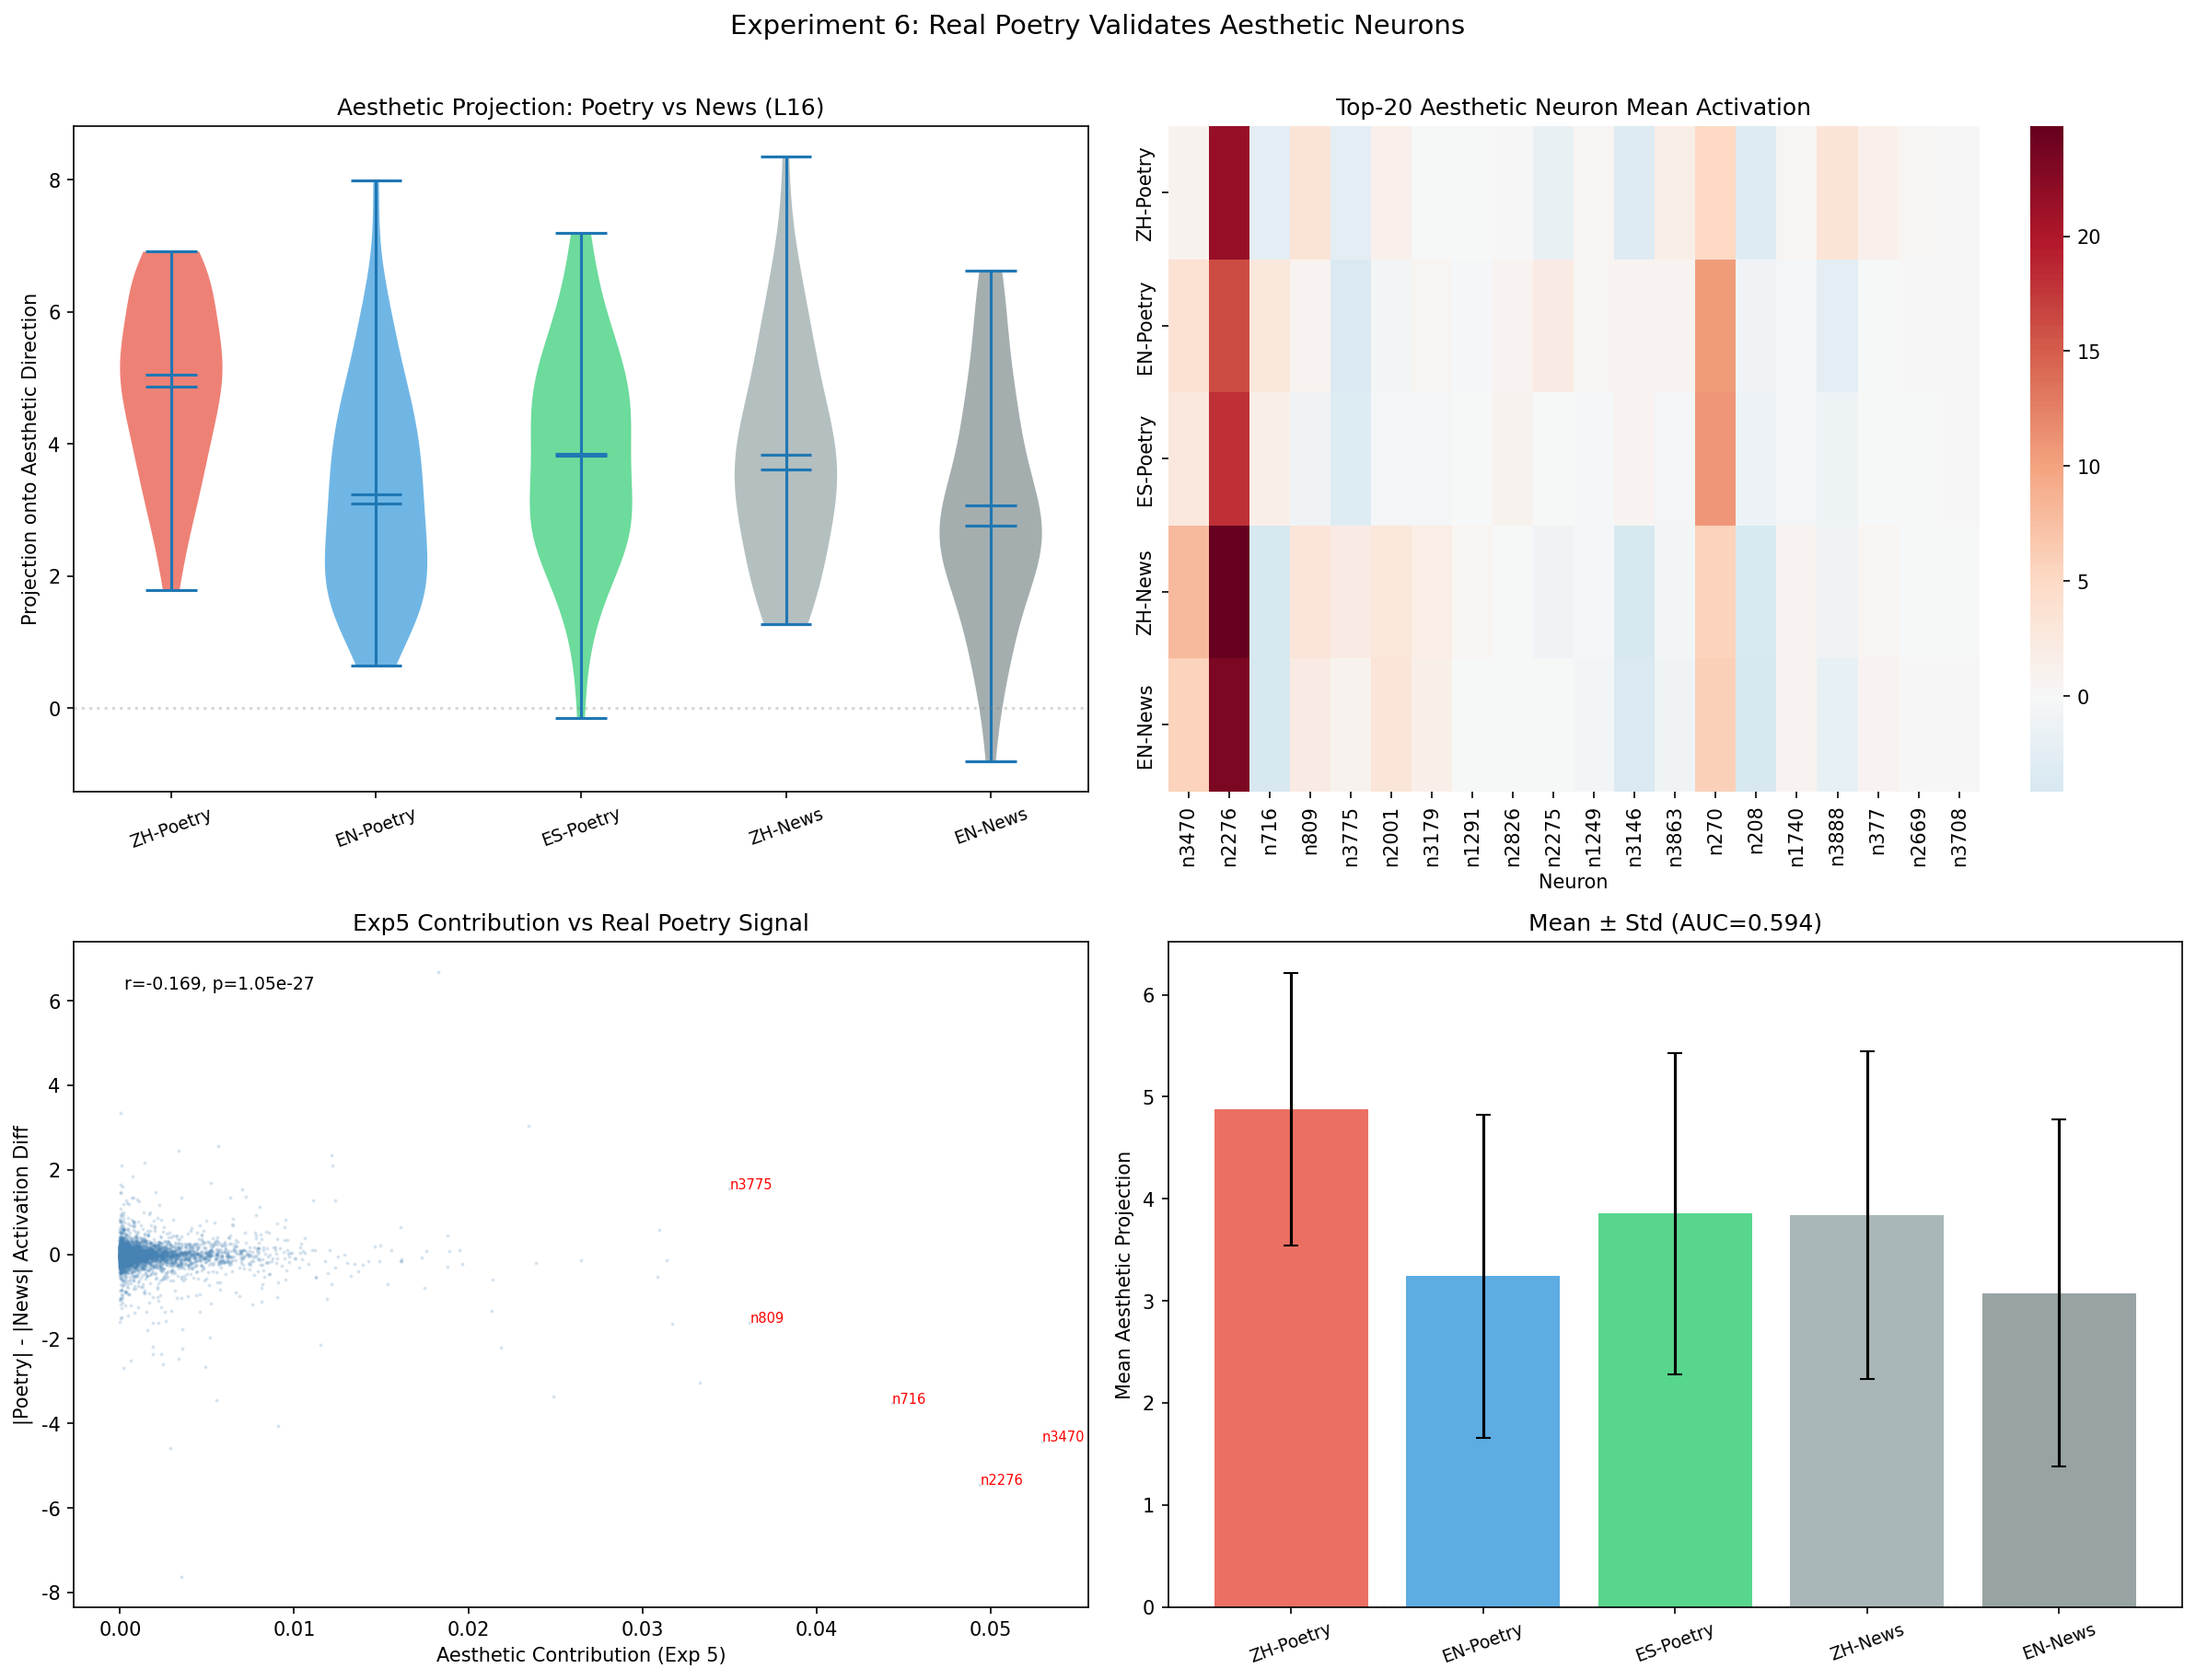

Saved: /workspace/Data/poetry_aesthetics/exp6_poetry_validation.png


In [6]:
# §6 Exp 6 Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Violin plot: aesthetic projection by category
ax = axes[0, 0]
categories = ['ZH-Poetry', 'EN-Poetry', 'ES-Poetry', 'ZH-News', 'EN-News']
colors_cat = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6', '#7f8c8d']
vdata = [proj[c] for c in categories]
parts = ax.violinplot(vdata, positions=range(len(categories)), showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_cat[i])
    pc.set_alpha(0.7)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=20, fontsize=9)
ax.set_ylabel('Projection onto Aesthetic Direction')
ax.set_title(f'Aesthetic Projection: Poetry vs News (L{best_layer})')
ax.axhline(0, color='gray', ls=':', alpha=0.3)

# (b) Top-100 neuron activation heatmap (poetry vs news means)
ax = axes[0, 1]
top20 = top_aesthetic[:20]
heatmap_data = np.zeros((5, 20))
for i, name in enumerate(categories):
    if name.endswith('Poetry'):
        acts_cat = {'ZH-Poetry': acts_zh_poetry, 'EN-Poetry': acts_en_poetry, 'ES-Poetry': acts_es_poetry}[name]
    else:
        acts_cat = {'ZH-News': acts_zh_news, 'EN-News': acts_en_news}[name]
    heatmap_data[i] = acts_cat[:, top20].mean(0)
sns.heatmap(heatmap_data, ax=ax, xticklabels=[f'n{n}' for n in top20],
            yticklabels=categories, cmap='RdBu_r', center=0, fmt='.1f')
ax.set_title('Top-20 Aesthetic Neuron Mean Activation')
ax.set_xlabel('Neuron')

# (c) Scatter: neuron contribution (Exp5) vs poetry-news activation diff
ax = axes[1, 0]
poetry_mean_all = acts_poetry_concat.mean(0)  # (4096,)
news_mean_all   = acts_news_concat.mean(0)    # (4096,)
act_diff = np.abs(poetry_mean_all) - np.abs(news_mean_all)
ax.scatter(contribution[best_layer], act_diff, s=1, alpha=0.15, c='steelblue')
for j in top_aesthetic[:5]:
    ax.annotate(f'n{j}', (contribution[best_layer, j], act_diff[j]),
                fontsize=7, color='red')
ax.set_xlabel('Aesthetic Contribution (Exp 5)')
ax.set_ylabel('|Poetry| - |News| Activation Diff')
ax.set_title('Exp5 Contribution vs Real Poetry Signal')
r, p = stats.pearsonr(contribution[best_layer], act_diff)
ax.text(0.05, 0.95, f'r={r:.3f}, p={p:.2e}', transform=ax.transAxes, fontsize=9, va='top')

# (d) Summary statistics bar chart
ax = axes[1, 1]
means = [proj[c].mean() for c in categories]
stds = [proj[c].std() for c in categories]
bars = ax.bar(range(len(categories)), means, yerr=stds, color=colors_cat, alpha=0.8, capsize=4)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=20, fontsize=9)
ax.set_ylabel('Mean Aesthetic Projection')
ax.set_title(f'Mean ± Std (AUC={auc:.3f})')
ax.axhline(0, color='gray', ls=':', alpha=0.3)

plt.suptitle('Experiment 6: Real Poetry Validates Aesthetic Neurons', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp6_poetry_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {OUTPUT_DIR / "exp6_poetry_validation.png"}')

## Experiment 7: Dynasty Aesthetics — Tang vs Song

**Question**: Does the model encode distinct aesthetic representations for Tang (唐) vs Song (宋) poetry?

**Context**: Tang poetry is stereotypically 奔放 (bold/expressive); Song poetry is 婉约 (restrained/delicate).  
If the model captures this, we should find:
1. A "dynasty direction" in activation space
2. Dynasty-specific neurons distinct from general aesthetic neurons
3. Causal evidence: steering can shift between Tang and Song styles

In [7]:
# §7 Prepare Tang vs Song samples + collect activations
N_DYNASTY = 50

tang_poems = zh_by_dynasty.get('唐代', [])
song_poems = zh_by_dynasty.get('宋代', [])

tang_idx = rng.choice(len(tang_poems), N_DYNASTY, replace=False)
song_idx = rng.choice(len(song_poems), N_DYNASTY, replace=False)

tang_texts = [tang_poems[i]['content'] for i in tang_idx]
song_texts = [song_poems[i]['content'] for i in song_idx]

print(f'Tang poems: {len(tang_texts)} (from {len(tang_poems)} total)')
print(f'Song poems: {len(song_texts)} (from {len(song_poems)} total)')
print(f'\nSample Tang: {tang_texts[0][:100]}')
print(f'Sample Song: {song_texts[0][:100]}')

# Collect activations — ALL layers this time for deeper analysis
print(f'\n=== Collecting ALL-layer activations ===')

def collect_all_layer_acts(texts, label, max_chars=300):
    """Collect activations at ALL layers for each text."""
    all_acts = []  # will be (N, N_LAYERS, N_EMBD)
    t0 = time.time()
    for i, text in enumerate(texts):
        engine.reset()
        ok = engine.forward(text[:max_chars])
        if ok:
            layer_acts = engine.get_all_activations()  # list of (4096,) × 36
            all_acts.append(np.stack(layer_acts))       # (36, 4096)
        if (i+1) % 25 == 0:
            print(f'  {label}: {i+1}/{len(texts)} ({time.time()-t0:.1f}s)')
    print(f'  {label}: {len(all_acts)}/{len(texts)} in {time.time()-t0:.1f}s')
    return np.array(all_acts)  # (N, 36, 4096)

tang_acts = collect_all_layer_acts(tang_texts, 'Tang')
song_acts = collect_all_layer_acts(song_texts, 'Song')
print(f'Tang: {tang_acts.shape}, Song: {song_acts.shape}')

Tang poems: 50 (from 2000 total)
Song poems: 50 (from 2000 total)

Sample Tang: 江寺禅僧似悟禅，坏衣芒履住茅轩。懒求施主修真像，
翻说经文是妄言。出浦钓船惊宿雁，伐岩樵斧迸寒猿。
行人莫问师宗旨，眼不浮华耳不喧。
Sample Song: 上人合动山间兴，吾恨衰迟学谢安。
纳屐操筇那有限，吹云落雨漫无端。
先戚报信春枝破，预想分题雪屋寒。
林下不谙人世苦，笑将霜鬓与君看。

=== Collecting ALL-layer activations ===
  Tang: 25/50 (1.3s)
  Tang: 50/50 (2.5s)
  Tang: 50/50 in 2.5s
  Song: 25/50 (1.3s)
  Song: 50/50 (2.5s)
  Song: 50/50 in 2.5s
Tang: (50, 36, 4096), Song: (50, 36, 4096)


In [8]:
# §8 Dynasty direction vector + classification
# Compute Tang-Song direction at each layer (same method as Exp2 aesthetic direction)

dynasty_dir = np.zeros((N_LAYERS, N_EMBD), dtype=np.float32)
dynasty_selectivity = np.zeros((N_LAYERS, N_EMBD), dtype=np.float32)

for L in range(N_LAYERS):
    t_acts = tang_acts[:, L, :]  # (50, 4096)
    s_acts = song_acts[:, L, :]  # (50, 4096)
    diff = t_acts.mean(0) - s_acts.mean(0)
    norm = np.linalg.norm(diff)
    dynasty_dir[L] = diff / max(norm, 1e-8)
    # Per-neuron selectivity (Cohen's d)
    pooled = np.sqrt((t_acts.std(0, ddof=1)**2 + s_acts.std(0, ddof=1)**2) / 2)
    dynasty_selectivity[L] = np.abs(diff) / np.maximum(pooled, 1e-8)

# --- Classification with dynasty direction ---
from sklearn.metrics import roc_auc_score
print(f'=== Tang vs Song Classification (layer-by-layer) ===')
best_dynasty_layer = -1
best_dynasty_auc = 0
dynasty_aucs = []
for L in range(N_LAYERS):
    t_proj = tang_acts[:, L, :] @ dynasty_dir[L]
    s_proj = song_acts[:, L, :] @ dynasty_dir[L]
    all_proj = np.concatenate([t_proj, s_proj])
    labels = np.array([1]*len(t_proj) + [0]*len(s_proj))
    auc_val = roc_auc_score(labels, all_proj)
    dynasty_aucs.append(auc_val)
    if auc_val > best_dynasty_auc:
        best_dynasty_auc = auc_val
        best_dynasty_layer = L

print(f'  Best dynasty layer: L{best_dynasty_layer} (AUC={best_dynasty_auc:.4f})')

# --- How aligned is dynasty direction with aesthetic direction? ---
cosines = []
for L in range(N_LAYERS):
    c = np.dot(dynasty_dir[L], aesthetic_dir_norm[L])
    cosines.append(c)
print(f'  Dynasty-Aesthetic cosine at L{best_layer}: {cosines[best_layer]:.4f}')
print(f'  Dynasty-Aesthetic cosine at L{best_dynasty_layer}: {cosines[best_dynasty_layer]:.4f}')

# --- Dynasty-specific neurons ---
# Neurons with high dynasty selectivity but LOW aesthetic contribution
L_d = best_dynasty_layer
dynasty_top = np.argsort(dynasty_selectivity[L_d])[-200:][::-1]
aesthetic_top_set = set(top_aesthetic[:200].tolist())
dynasty_only = [n for n in dynasty_top if n not in aesthetic_top_set]
aesthetic_only = [n for n in top_aesthetic[:200] if n not in set(dynasty_top.tolist())]
shared_neurons = [n for n in dynasty_top if n in aesthetic_top_set]

print(f'\n=== Neuron Overlap at L{L_d} (top-200 each) ===')
print(f'  Dynasty-specific: {len(dynasty_only)} neurons')
print(f'  Aesthetic-only:   {len(aesthetic_only)} neurons')
print(f'  Shared:           {len(shared_neurons)} neurons')
print(f'  Overlap ratio:    {len(shared_neurons)/200:.1%}')

=== Tang vs Song Classification (layer-by-layer) ===
  Best dynasty layer: L11 (AUC=0.9220)
  Dynasty-Aesthetic cosine at L16: -0.0222
  Dynasty-Aesthetic cosine at L11: 0.0080

=== Neuron Overlap at L11 (top-200 each) ===
  Dynasty-specific: 195 neurons
  Aesthetic-only:   95 neurons
  Shared:           5 neurons
  Overlap ratio:    2.5%


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

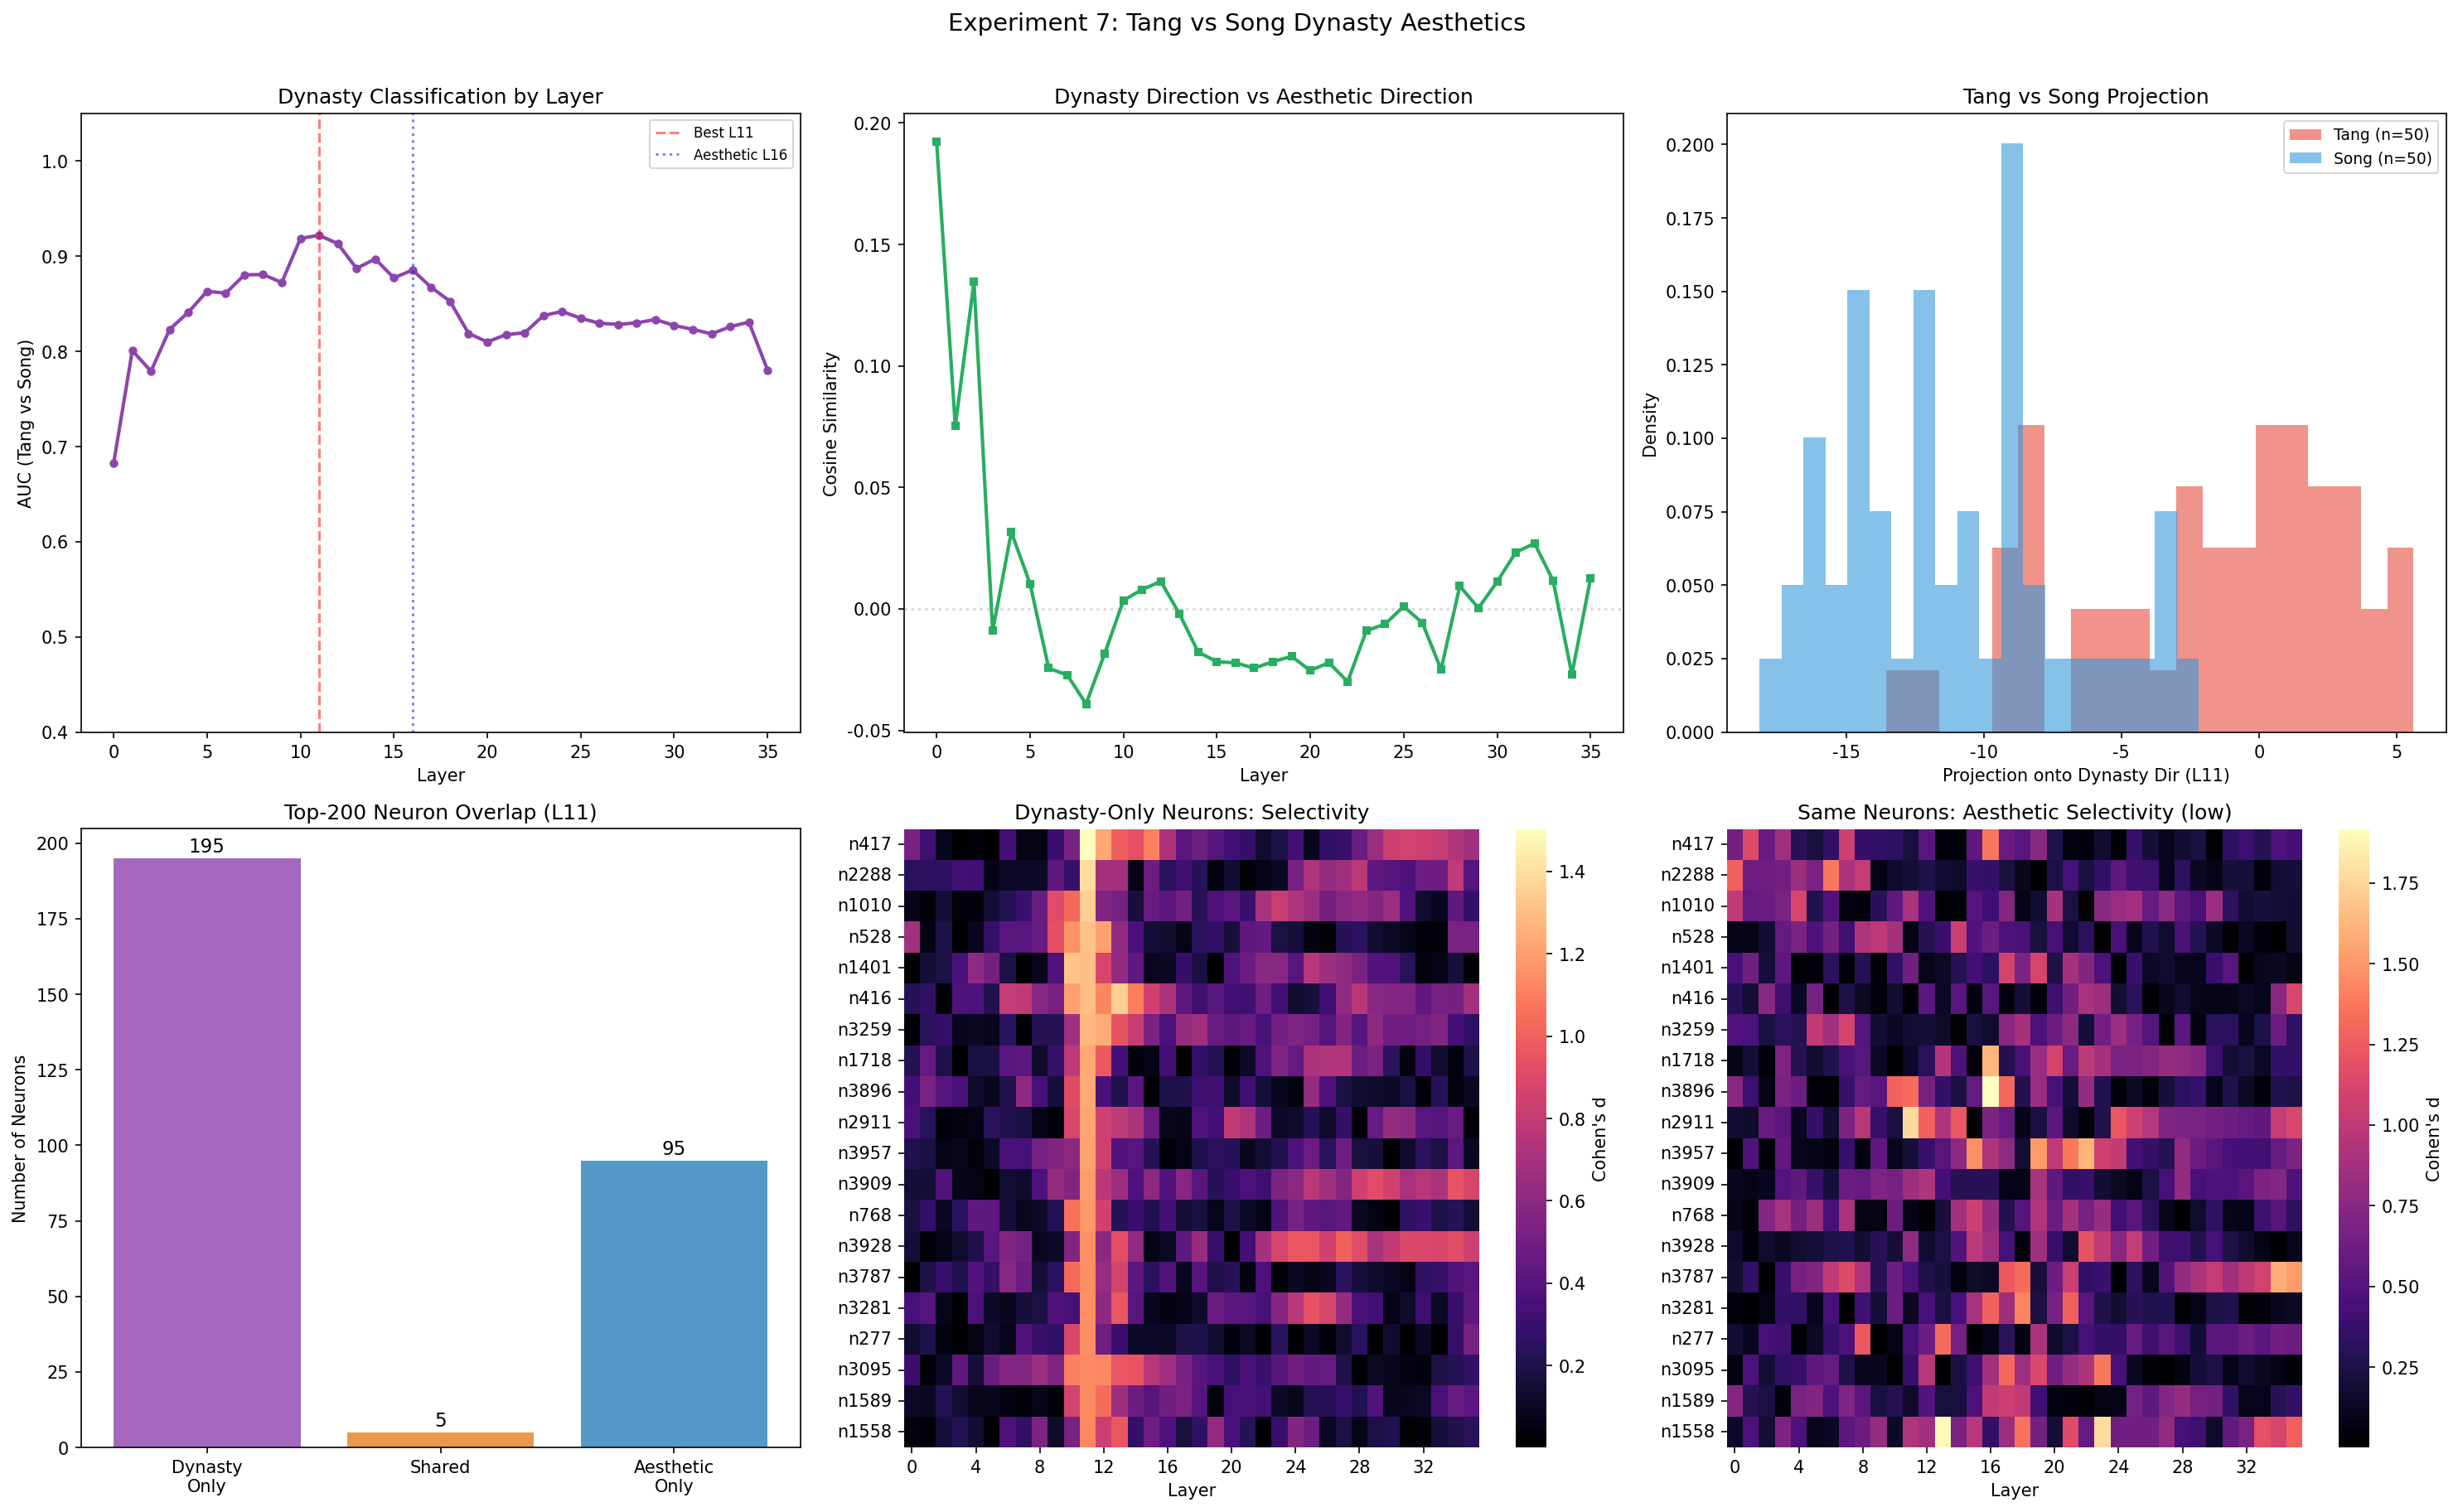

Saved: /workspace/Data/poetry_aesthetics/exp7_dynasty_aesthetics.png


In [9]:
# §9 Exp 7 Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# (a) AUC by layer
ax = axes[0, 0]
ax.plot(range(N_LAYERS), dynasty_aucs, 'o-', color='#8e44ad', lw=2, markersize=4)
ax.axvline(best_dynasty_layer, color='red', ls='--', alpha=0.5, label=f'Best L{best_dynasty_layer}')
ax.axvline(best_layer, color='blue', ls=':', alpha=0.5, label=f'Aesthetic L{best_layer}')
ax.set_xlabel('Layer'); ax.set_ylabel('AUC (Tang vs Song)')
ax.set_title('Dynasty Classification by Layer')
ax.legend(fontsize=8); ax.set_ylim(0.4, 1.05)

# (b) Dynasty-Aesthetic alignment
ax = axes[0, 1]
ax.plot(range(N_LAYERS), cosines, 's-', color='#27ae60', lw=2, markersize=4)
ax.axhline(0, color='gray', ls=':', alpha=0.3)
ax.set_xlabel('Layer'); ax.set_ylabel('Cosine Similarity')
ax.set_title('Dynasty Direction vs Aesthetic Direction')

# (c) Projection distributions at best dynasty layer
ax = axes[0, 2]
t_proj_best = tang_acts[:, L_d, :] @ dynasty_dir[L_d]
s_proj_best = song_acts[:, L_d, :] @ dynasty_dir[L_d]
ax.hist(t_proj_best, bins=20, alpha=0.6, color='#e74c3c', label=f'Tang (n={len(t_proj_best)})', density=True)
ax.hist(s_proj_best, bins=20, alpha=0.6, color='#3498db', label=f'Song (n={len(s_proj_best)})', density=True)
ax.set_xlabel(f'Projection onto Dynasty Dir (L{L_d})')
ax.set_ylabel('Density'); ax.set_title('Tang vs Song Projection')
ax.legend(fontsize=9)

# (d) Venn-style neuron overlap
ax = axes[1, 0]
overlap_categories = ['Dynasty\nOnly', 'Shared', 'Aesthetic\nOnly']
overlap_counts = [len(dynasty_only), len(shared_neurons), len(aesthetic_only)]
overlap_colors = ['#8e44ad', '#e67e22', '#2980b9']
bars = ax.bar(overlap_categories, overlap_counts, color=overlap_colors, alpha=0.8)
for bar, c in zip(bars, overlap_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(c),
            ha='center', fontsize=11)
ax.set_ylabel('Number of Neurons')
ax.set_title(f'Top-200 Neuron Overlap (L{L_d})')

# (e) Dynasty selectivity heatmap (top-20 dynasty neurons across layers)
ax = axes[1, 1]
top20_dynasty = np.array(dynasty_only[:20])
if len(top20_dynasty) > 0:
    hmap = dynasty_selectivity[:, top20_dynasty].T  # (20, 36)
    sns.heatmap(hmap, ax=ax, xticklabels=4, yticklabels=[f'n{n}' for n in top20_dynasty],
                cmap='magma', cbar_kws={'label': "Cohen's d"})
    ax.set_xlabel('Layer'); ax.set_title('Dynasty-Only Neurons: Selectivity')

# (f) Aesthetic selectivity heatmap of same neurons (to show they're low)
ax = axes[1, 2]
if len(top20_dynasty) > 0:
    hmap2 = selectivity[:, top20_dynasty].T  # (20, 36)
    sns.heatmap(hmap2, ax=ax, xticklabels=4, yticklabels=[f'n{n}' for n in top20_dynasty],
                cmap='magma', cbar_kws={'label': "Cohen's d"})
    ax.set_xlabel('Layer'); ax.set_title('Same Neurons: Aesthetic Selectivity (low)')

plt.suptitle('Experiment 7: Tang vs Song Dynasty Aesthetics', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp7_dynasty_aesthetics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "exp7_dynasty_aesthetics.png"}')

In [10]:
# §10 Dynasty Steering — causal validation
# Can we steer the model to write Tang-style vs Song-style descriptions?

STEER_STRENGTH = 5.0
L_steer = best_dynasty_layer

# Dynasty steering vector: Tang direction at best dynasty layer
tang_steer_vec = dynasty_dir[L_steer].astype(np.float32)  # pointing toward Tang

prompt_text = 'Please write a short Chinese poem about moonlight on a river. Write in Chinese.'
messages = [{'role': 'user', 'content': prompt_text}]
templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX

# (1) Baseline
engine.reset()
engine.clear_interventions()
out_baseline = engine.generate(templated, max_tokens=200, temperature=0.0)

# (2) Steer toward Tang (bold/expressive)
engine.reset()
engine.clear_interventions()
engine.apply_steering(L_steer, tang_steer_vec, float(STEER_STRENGTH))
out_tang = engine.generate(templated, max_tokens=200, temperature=0.0)
engine.clear_interventions()

# (3) Steer toward Song (restrained/delicate) = negative Tang direction
engine.reset()
engine.clear_interventions()
engine.apply_steering(L_steer, -tang_steer_vec, float(STEER_STRENGTH))
out_song = engine.generate(templated, max_tokens=200, temperature=0.0)
engine.clear_interventions()

print('=== Dynasty Steering Results ===')
print(f'Prompt: {prompt_text}')
print(f'Steering layer: L{L_steer}, strength: {STEER_STRENGTH}')
print(f'\n--- Baseline ---')
print(out_baseline[:500])
print(f'\n--- Tang-steered (bold/expressive) ---')
print(out_tang[:500])
print(f'\n--- Song-steered (restrained/delicate) ---')
print(out_song[:500])

# Try a second prompt
prompt2 = 'Please write a short Chinese poem about autumn mountains. Write in Chinese.'
messages2 = [{'role': 'user', 'content': prompt2}]
templated2 = engine.apply_chat_template(messages2) + NOTHINK_SUFFIX

engine.reset(); engine.clear_interventions()
out_base2 = engine.generate(templated2, max_tokens=200, temperature=0.0)

engine.reset(); engine.clear_interventions()
engine.apply_steering(L_steer, tang_steer_vec, float(STEER_STRENGTH))
out_tang2 = engine.generate(templated2, max_tokens=200, temperature=0.0)
engine.clear_interventions()

engine.reset(); engine.clear_interventions()
engine.apply_steering(L_steer, -tang_steer_vec, float(STEER_STRENGTH))
out_song2 = engine.generate(templated2, max_tokens=200, temperature=0.0)
engine.clear_interventions()

print(f'\n\n=== Second Prompt: Autumn Mountains ===')
print(f'--- Baseline ---\n{out_base2[:500]}')
print(f'\n--- Tang-steered ---\n{out_tang2[:500]}')
print(f'\n--- Song-steered ---\n{out_song2[:500]}')

=== Dynasty Steering Results ===
Prompt: Please write a short Chinese poem about moonlight on a river. Write in Chinese.
Steering layer: L11, strength: 5.0

--- Baseline ---
月光洒河面，  
波光映夜天。  
轻舟随水动，  
静影伴梦眠。

--- Tang-steered (bold/expressive) ---
月光洒江面，  
波光映银辉。  
轻舟随水动，  
静影伴梦归。

--- Song-steered (restrained/delicate) ---
月光洒河面，  
波光映夜天。  
轻舟随水动，  
静影伴星眠。


=== Second Prompt: Autumn Mountains ===
--- Baseline ---
秋山寂寂叶初黄，  
云淡风轻雁远翔。  
万壑千峰皆入画，  
一川烟水映斜阳。

--- Tang-steered ---
秋山寂寂叶初黄，  
云淡风轻雁远翔。  
石径幽深人迹少，  
松声潺潺伴斜阳。

--- Song-steered ---
秋山寂寂叶初黄，  
云淡风轻雁远翔。  
万壑千峰皆入画，  
一川烟水映斜阳。


## Experiment 8: Bilingual Aesthetic Distillation

**Question**: When the same poem exists in both Chinese and English, which neurons respond to **content** (shared) vs **language-specific style**?

**Method**: For each bilingual pair (ZH original, EN translation):
1. Collect activations for both versions
2. Compute per-neuron correlation across pairs → high correlation = content neuron
3. Neurons that diverge = language-specific aesthetic style neurons
4. Use these to build more precise "pure style" steering vectors

In [11]:
# §11 Collect bilingual activations
N_BI = min(100, len(bilingual_all))  # use up to 100 pairs
bi_pairs = bilingual_all[:N_BI]

print(f'Collecting activations for {N_BI} bilingual pairs...')
bi_zh_acts = []  # (N, 4096) at best_layer
bi_en_acts = []

t0 = time.time()
for i, pair in enumerate(bi_pairs):
    zh_text = pair['source']
    en_text = pair['target']
    
    engine.reset()
    ok_zh = engine.forward(zh_text[:300])
    if ok_zh:
        zh_act = engine.get_activations(best_layer).copy()
    else:
        zh_act = np.zeros(N_EMBD, dtype=np.float32)
    
    engine.reset()
    ok_en = engine.forward(en_text[:300])
    if ok_en:
        en_act = engine.get_activations(best_layer).copy()
    else:
        en_act = np.zeros(N_EMBD, dtype=np.float32)
    
    bi_zh_acts.append(zh_act)
    bi_en_acts.append(en_act)
    
    if (i+1) % 50 == 0:
        print(f'  {i+1}/{N_BI} pairs ({time.time()-t0:.1f}s)')

bi_zh_acts = np.array(bi_zh_acts)  # (N, 4096)
bi_en_acts = np.array(bi_en_acts)  # (N, 4096)
print(f'Collected: ZH={bi_zh_acts.shape}, EN={bi_en_acts.shape} in {time.time()-t0:.1f}s')

  50/100 pairs (4.3s)
  100/100 pairs (8.6s)
Collected: ZH=(100, 4096), EN=(100, 4096) in 8.6s


In [12]:
# §12 Bilingual analysis: content vs style neurons
# For each neuron: compute Pearson correlation of ZH activation vs EN activation across pairs
# High correlation → neuron responds to CONTENT (same meaning, both languages activate similarly)
# Low/negative correlation → neuron responds to LANGUAGE-SPECIFIC STYLE

neuron_corr = np.zeros(N_EMBD)
neuron_corr_p = np.zeros(N_EMBD)
for j in range(N_EMBD):
    zh_vals = bi_zh_acts[:, j]
    en_vals = bi_en_acts[:, j]
    if zh_vals.std() > 1e-8 and en_vals.std() > 1e-8:
        r, p = stats.pearsonr(zh_vals, en_vals)
        neuron_corr[j] = r
        neuron_corr_p[j] = p
    else:
        neuron_corr[j] = 0.0
        neuron_corr_p[j] = 1.0

# Classify neurons
CONTENT_THRESH = 0.5    # high cross-language correlation
STYLE_THRESH = 0.1      # low cross-language correlation
content_neurons = np.where(neuron_corr > CONTENT_THRESH)[0]
style_neurons = np.where(neuron_corr < STYLE_THRESH)[0]
ambiguous_neurons = np.where((neuron_corr >= STYLE_THRESH) & (neuron_corr <= CONTENT_THRESH))[0]

print(f'=== Bilingual Neuron Classification (L{best_layer}) ===')
print(f'  Content neurons (r > {CONTENT_THRESH}):  {len(content_neurons)}')
print(f'  Style neurons (r < {STYLE_THRESH}):     {len(style_neurons)}')
print(f'  Ambiguous:                      {len(ambiguous_neurons)}')
print(f'  Mean correlation: {neuron_corr.mean():.4f}')

# How do aesthetic neurons partition?
top100_set = set(top_aesthetic[:100].tolist())
aesthetic_content = len([n for n in content_neurons if n in top100_set])
aesthetic_style = len([n for n in style_neurons if n in top100_set])
print(f'\n=== Top-100 Aesthetic Neurons Partition ===')
print(f'  Content (shared across ZH/EN): {aesthetic_content}')
print(f'  Style (language-specific):     {aesthetic_style}')
print(f'  Other:                         {100 - aesthetic_content - aesthetic_style}')

# Direction analysis: do content neurons dominate the aesthetic direction?
content_mask = np.zeros(N_EMBD)
content_mask[content_neurons] = 1.0
style_mask = np.zeros(N_EMBD)
style_mask[style_neurons] = 1.0

d_vec = aesthetic_dir_norm[best_layer]
content_contrib = np.sum(np.abs(d_vec * content_mask)) / np.sum(np.abs(d_vec))
style_contrib = np.sum(np.abs(d_vec * style_mask)) / np.sum(np.abs(d_vec))
print(f'\n=== Contribution to Aesthetic Direction ===')
print(f'  Content neurons: {content_contrib:.1%} of total |direction|')
print(f'  Style neurons:   {style_contrib:.1%} of total |direction|')

=== Bilingual Neuron Classification (L16) ===
  Content neurons (r > 0.5):  10
  Style neurons (r < 0.1):     1554
  Ambiguous:                      2532
  Mean correlation: 0.1351

=== Top-100 Aesthetic Neurons Partition ===
  Content (shared across ZH/EN): 4
  Style (language-specific):     29
  Other:                         67

=== Contribution to Aesthetic Direction ===
  Content neurons: 0.5% of total |direction|
  Style neurons:   36.1% of total |direction|


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

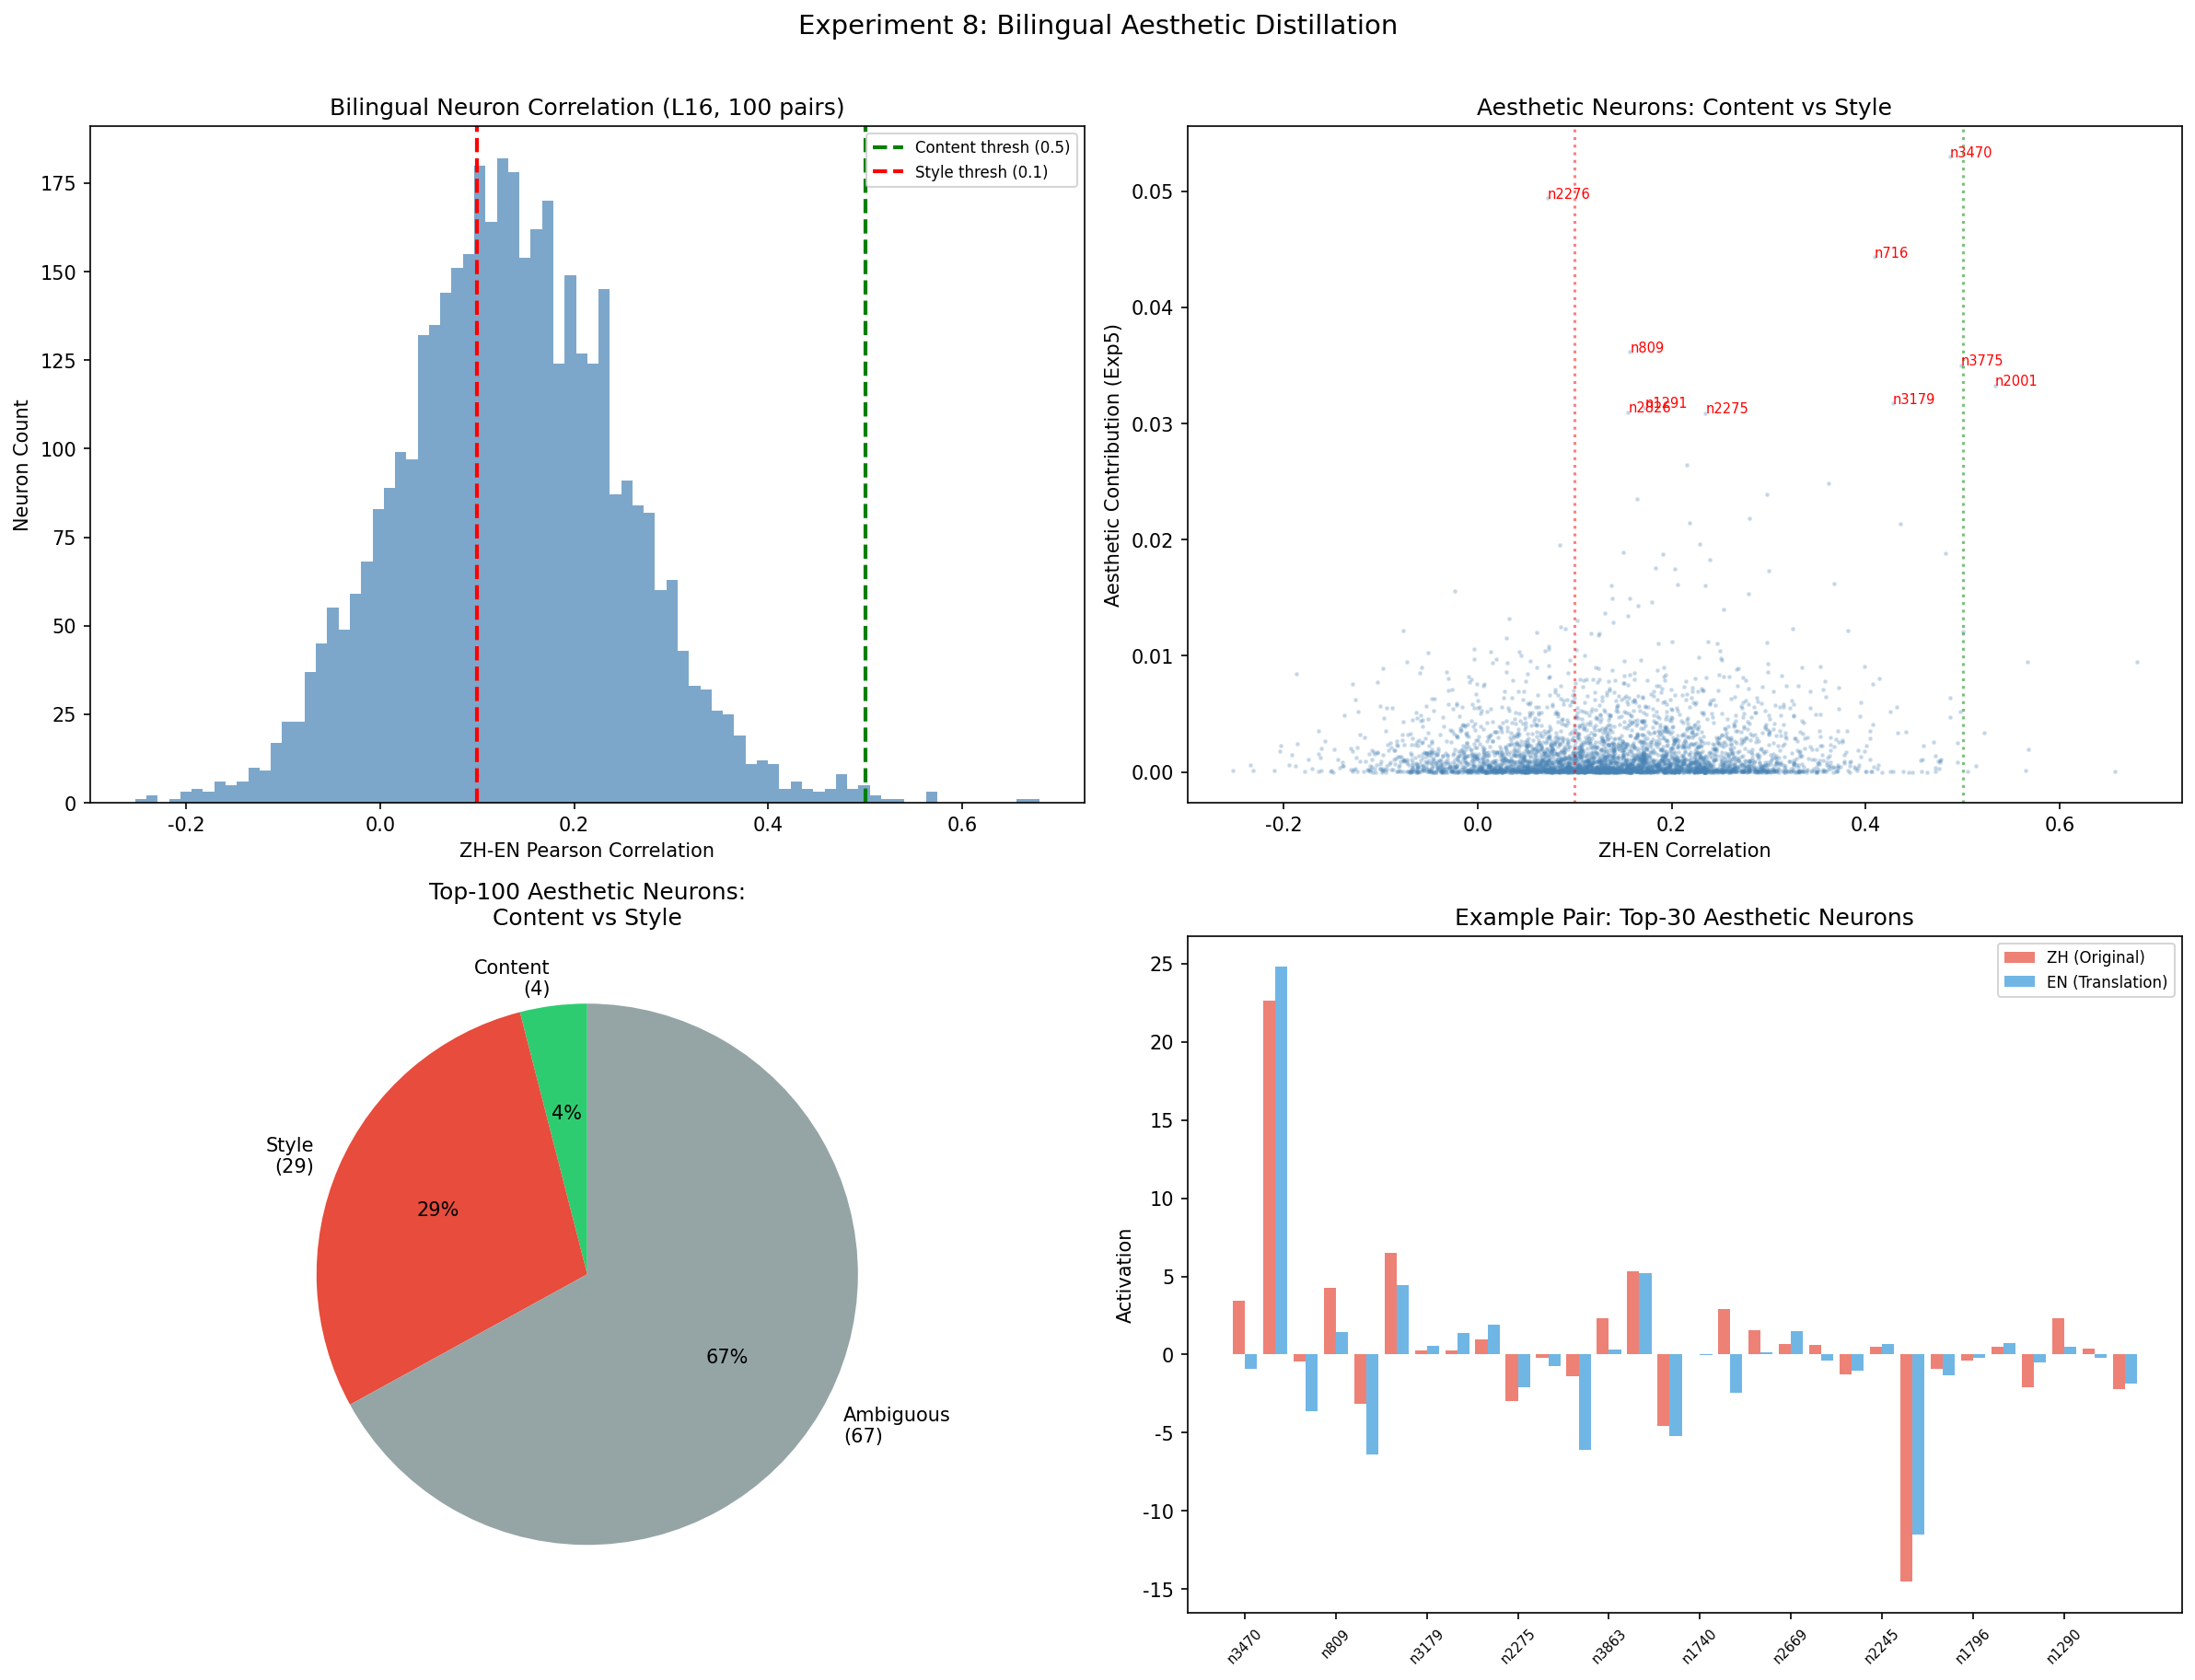

Saved: /workspace/Data/poetry_aesthetics/exp8_bilingual_distillation.png


In [13]:
# §13 Exp 8 Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Correlation histogram
ax = axes[0, 0]
ax.hist(neuron_corr, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
ax.axvline(CONTENT_THRESH, color='green', ls='--', lw=2, label=f'Content thresh ({CONTENT_THRESH})')
ax.axvline(STYLE_THRESH, color='red', ls='--', lw=2, label=f'Style thresh ({STYLE_THRESH})')
ax.set_xlabel('ZH-EN Pearson Correlation')
ax.set_ylabel('Neuron Count')
ax.set_title(f'Bilingual Neuron Correlation (L{best_layer}, {N_BI} pairs)')
ax.legend(fontsize=8)

# (b) Scatter: aesthetic contribution vs bilingual correlation
ax = axes[0, 1]
ax.scatter(neuron_corr, contribution[best_layer], s=2, alpha=0.2, c='steelblue')
for j in top_aesthetic[:10]:
    ax.annotate(f'n{j}', (neuron_corr[j], contribution[best_layer, j]),
                fontsize=7, color='red')
ax.axvline(CONTENT_THRESH, color='green', ls=':', alpha=0.5)
ax.axvline(STYLE_THRESH, color='red', ls=':', alpha=0.5)
ax.set_xlabel('ZH-EN Correlation')
ax.set_ylabel('Aesthetic Contribution (Exp5)')
ax.set_title('Aesthetic Neurons: Content vs Style')

# (c) Pie chart: aesthetic neuron partition
ax = axes[1, 0]
sizes = [aesthetic_content, aesthetic_style, 100 - aesthetic_content - aesthetic_style]
labels_pie = [f'Content\n({aesthetic_content})', f'Style\n({aesthetic_style})',
              f'Ambiguous\n({100-aesthetic_content-aesthetic_style})']
colors_pie = ['#2ecc71', '#e74c3c', '#95a5a6']
ax.pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%1.0f%%',
       startangle=90, textprops={'fontsize': 10})
ax.set_title('Top-100 Aesthetic Neurons:\nContent vs Style')

# (d) Example pair comparison
ax = axes[1, 1]
# Show activation profile for one pair
example_idx = 0
zh_act_ex = bi_zh_acts[example_idx, top_aesthetic[:30]]
en_act_ex = bi_en_acts[example_idx, top_aesthetic[:30]]
x = np.arange(30)
ax.bar(x - 0.2, zh_act_ex, 0.4, label='ZH (Original)', color='#e74c3c', alpha=0.7)
ax.bar(x + 0.2, en_act_ex, 0.4, label='EN (Translation)', color='#3498db', alpha=0.7)
ax.set_xticks(x[::3])
ax.set_xticklabels([f'n{n}' for n in top_aesthetic[:30:3]], fontsize=7, rotation=45)
ax.set_ylabel('Activation')
ax.set_title(f'Example Pair: Top-30 Aesthetic Neurons')
ax.legend(fontsize=8)

plt.suptitle('Experiment 8: Bilingual Aesthetic Distillation', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp8_bilingual_distillation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "exp8_bilingual_distillation.png"}')

In [14]:
# §14 Save all results + Summary
np.savez(OUTPUT_DIR / 'exp6_results.npz',
    proj_zh_poetry=proj['ZH-Poetry'], proj_en_poetry=proj['EN-Poetry'],
    proj_es_poetry=proj['ES-Poetry'], proj_zh_news=proj['ZH-News'],
    proj_en_news=proj['EN-News'],
    acts_zh_poetry=acts_zh_poetry, acts_en_poetry=acts_en_poetry,
    acts_es_poetry=acts_es_poetry, acts_zh_news=acts_zh_news,
    acts_en_news=acts_en_news,
    auc_poetry_vs_news=auc,
)

np.savez(OUTPUT_DIR / 'exp7_results.npz',
    dynasty_dir=dynasty_dir, dynasty_selectivity=dynasty_selectivity,
    dynasty_aucs=np.array(dynasty_aucs),
    tang_acts=tang_acts, song_acts=song_acts,
    best_dynasty_layer=best_dynasty_layer,
    dynasty_only_neurons=np.array(dynasty_only[:100]),
    shared_neurons=np.array(shared_neurons[:100]),
)

np.savez(OUTPUT_DIR / 'exp8_results.npz',
    bi_zh_acts=bi_zh_acts, bi_en_acts=bi_en_acts,
    neuron_corr=neuron_corr, neuron_corr_p=neuron_corr_p,
    content_neurons=content_neurons, style_neurons=style_neurons,
)

# Steering text results
with open(OUTPUT_DIR / 'exp7_steering_texts.json', 'w', encoding='utf-8') as f:
    json.dump({
        'moonlight': {'baseline': out_baseline, 'tang': out_tang, 'song': out_song},
        'autumn': {'baseline': out_base2, 'tang': out_tang2, 'song': out_song2},
    }, f, ensure_ascii=False, indent=2)

print('='*65)
print('EXPERIMENTS 6-8 SUMMARY')
print('='*65)
print(f'\nExp 6 — Real Poetry Validation:')
print(f'  Poetry vs News AUC: {auc:.4f}')
print(f'  Poetry mean proj: {poetry_all.mean():.3f}, News: {news_all.mean():.3f}')
print(f'  Cohen\'s d: {cohens_d:.3f}')
print(f'  Top-100 aesthetic neurons higher for poetry: {(top_diff > 0).sum()}/100')

print(f'\nExp 7 — Dynasty Aesthetics:')
print(f'  Tang vs Song AUC: {best_dynasty_auc:.4f} (L{best_dynasty_layer})')
print(f'  Dynasty-Aesthetic cosine: {cosines[best_layer]:.4f}')
print(f'  Dynasty-only neurons: {len(dynasty_only)}, Shared: {len(shared_neurons)}')

print(f'\nExp 8 — Bilingual Distillation:')
print(f'  Content neurons (r>{CONTENT_THRESH}): {len(content_neurons)}')
print(f'  Style neurons (r<{STYLE_THRESH}): {len(style_neurons)}')
print(f'  Aesthetic neurons: {aesthetic_content} content, {aesthetic_style} style')
print(f'  Content contribution to aesthetic dir: {content_contrib:.1%}')

print(f'\nAll results saved to: {OUTPUT_DIR}')
print('='*65)

EXPERIMENTS 6-8 SUMMARY

Exp 6 — Real Poetry Validation:
  Poetry vs News AUC: 0.5937
  Poetry mean proj: 3.990, News: 3.460
  Cohen's d: 0.317
  Top-100 aesthetic neurons higher for poetry: 41/100

Exp 7 — Dynasty Aesthetics:
  Tang vs Song AUC: 0.9220 (L11)
  Dynasty-Aesthetic cosine: -0.0222
  Dynasty-only neurons: 195, Shared: 5

Exp 8 — Bilingual Distillation:
  Content neurons (r>0.5): 10
  Style neurons (r<0.1): 1554
  Aesthetic neurons: 4 content, 29 style
  Content contribution to aesthetic dir: 0.5%

All results saved to: /workspace/Data/poetry_aesthetics
